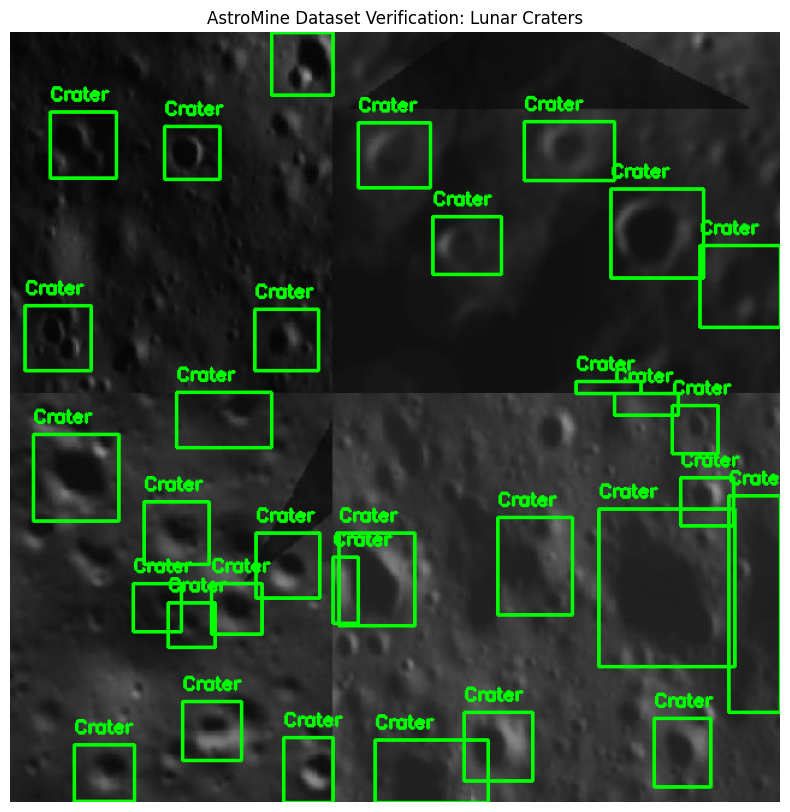

In [1]:
import cv2
import matplotlib.pyplot as plt
import os

# 1. Define paths
image_dir = '../dataset/train/images/'
label_dir = '../dataset/train/labels/'

# 2. Grab the first image we find
image_files = os.listdir(image_dir)
if not image_files:
    print("No images found. Check your folder path!")
else:
    sample_img_name = image_files[0]
    sample_lbl_name = sample_img_name.replace('.jpg', '.txt')
    
    # 3. Load image
    img_path = os.path.join(image_dir, sample_img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Fix colors for matplotlib
    height, width, _ = img.shape

    # 4. Read the YOLO label file
    label_path = os.path.join(label_dir, sample_lbl_name)
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
            for line in lines:
                # YOLO format: class x_center y_center box_width box_height
                parts = line.strip().split()
                class_id = int(parts[0])
                x_center, y_center, w, h = map(float, parts[1:])
                
                # Convert YOLO normalized coordinates back to actual pixels
                x1 = int((x_center - w/2) * width)
                y1 = int((y_center - h/2) * height)
                x2 = int((x_center + w/2) * width)
                y2 = int((y_center + h/2) * height)
                
                # Draw a bright green rectangle around the crater
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, "Crater", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 5. Display the cinematic result
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("AstroMine Dataset Verification: Lunar Craters")
    plt.show()